# Facial Expression Recognition - Dataset Overview
- Phân tích cấu trúc dữ liệu
- Phân phối các lớp (emotion)
- Thuộc tính của ảnh

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

# Set visual aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

## 1. Data Loading & Statistics
Đầu tiên, chúng ta định nghĩa đường dẫn và load các file CSV cho: Train || Validation || Test

In [7]:
# Path to data directory
DATA_DIR = "../../data/fer_data/"
train_path = os.path.join(DATA_DIR, "train.csv")
val_path = os.path.join(DATA_DIR, "val.csv")
test_path = os.path.join(DATA_DIR, "test.csv")

# Load datasets
df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

print(f"Train samples: {len(df_train)}")
print(f"Validation samples: {len(df_val)}")
print(f"Test samples: {len(df_test)}")
print(f"Total samples: {len(df_train) + len(df_val) + len(df_test)}")

Train samples: 28709
Validation samples: 3589
Test samples: 3589
Total samples: 35887


## 2. Class Distribution Analysis
Chúng ta ánh xạ các label số (0–6) sang tên cảm xúc dễ hiểu và visualize phân phối.

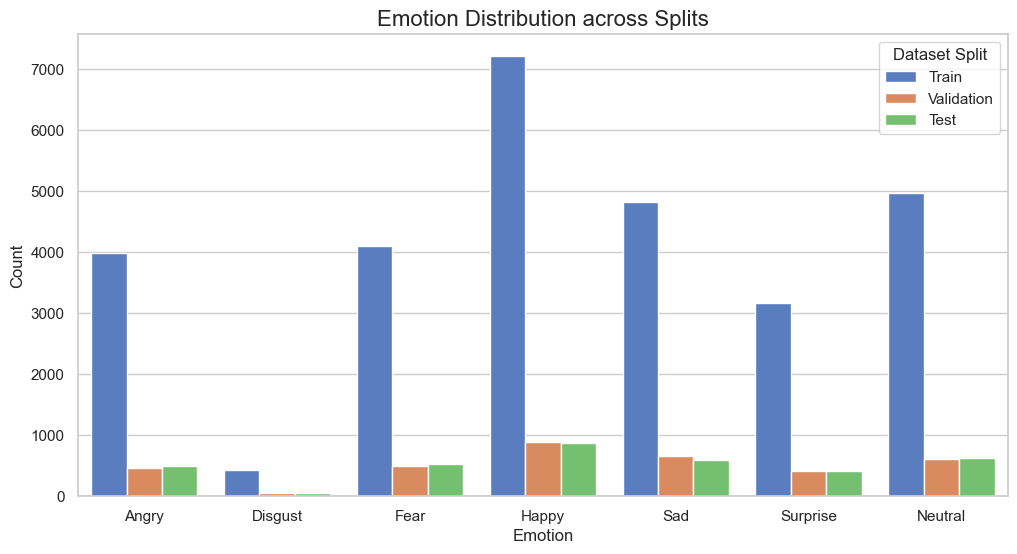

In [8]:
# Emotion mapping (Common FER2013 convention)
EMOTIONS_MAP = {
    0: 'Angry', 
    1: 'Disgust', 
    2: 'Fear', 
    3: 'Happy', 
    4: 'Sad', 
    5: 'Surprise', 
    6: 'Neutral'
}

def process_df(df, split_name):
    df['emotion_label'] = df['emotion'].map(EMOTIONS_MAP)
    df['split'] = split_name
    return df

df_train = process_df(df_train, 'Train')
df_val = process_df(df_val, 'Validation')
df_test = process_df(df_test, 'Test')

# Combine for total distribution
df_all = pd.concat([df_train, df_val, df_test])

# Visualization
plt.figure(figsize=(12, 6))
sns.countplot(data=df_all, x='emotion_label', hue='split', order=EMOTIONS_MAP.values())
plt.title("Emotion Distribution across Splits")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.legend(title="Dataset Split")
plt.show()

## 3. Image Properties Verification
Xác nhận rằng ảnh có kích thước 48x48 và grayscale đúng như mô tả.

In [9]:
def pixels_to_array(pixels_str):
    return np.array(pixels_str.split(), dtype='int').reshape(48, 48)

# Verify first image shape
sample_image = pixels_to_array(df_train['pixels'].iloc[0])
print(f"Sample image shape: {sample_image.shape}")
print(f"Image size confirmed as 48x48: {sample_image.shape == (48, 48)}")
print(f"Data type: {sample_image.dtype}")

Sample image shape: (48, 48)
Image size confirmed as 48x48: True
Data type: int64


## 4. Visualizing Sample Images
Hiển thị một số ảnh cho mỗi loại cảm xúc để hiểu sự khác biệt.

Visualizing samples from Training set:


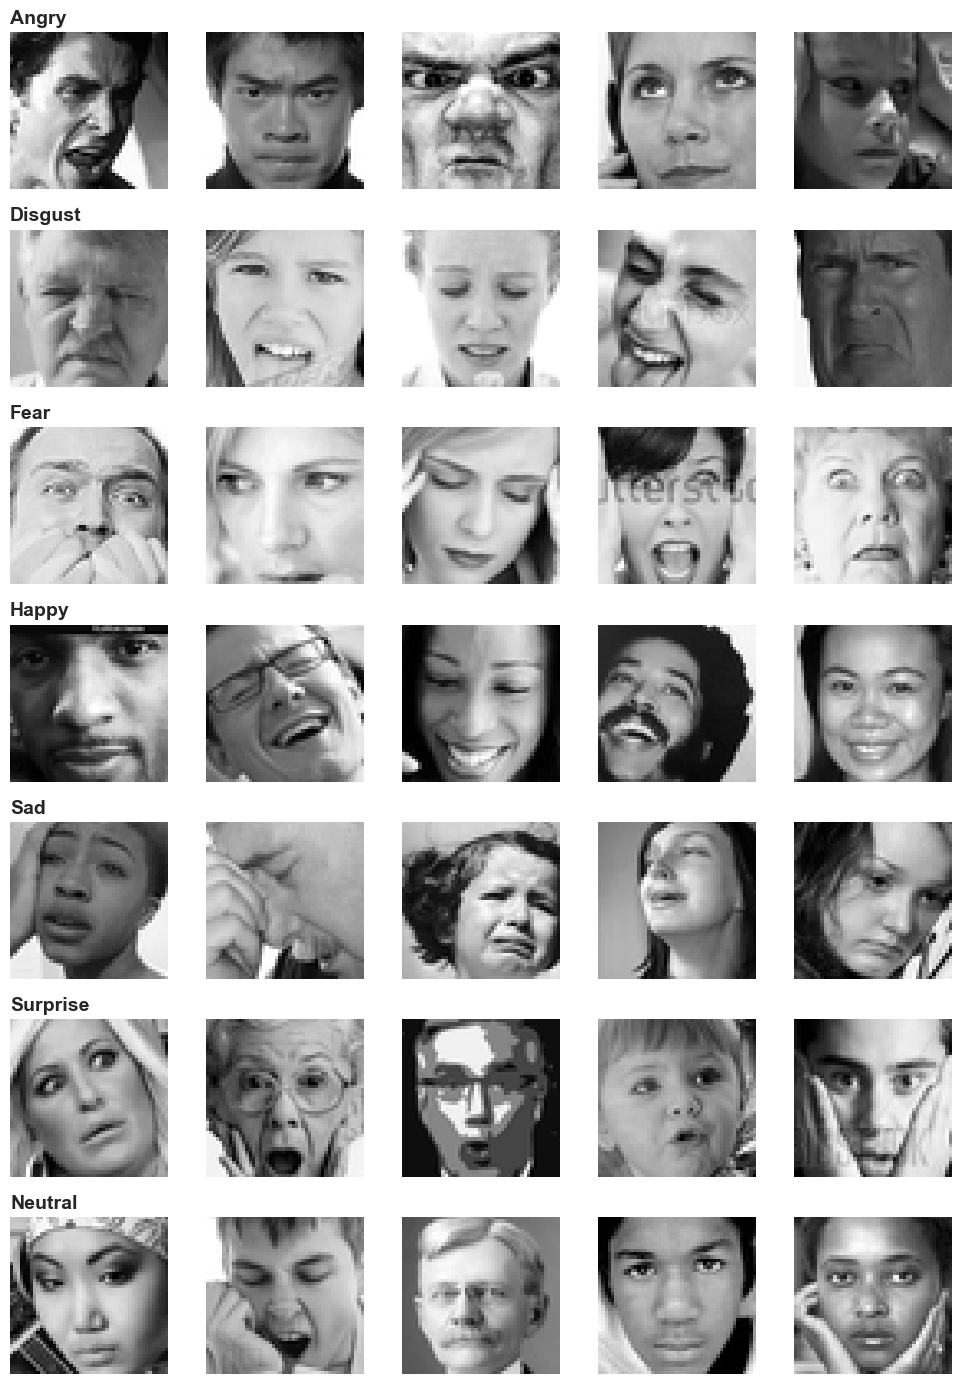

In [10]:
def plot_emotion_samples(df, emotions_map, n_samples=5):
    n_emotions = len(emotions_map)
    fig, axes = plt.subplots(n_emotions, n_samples, figsize=(n_samples * 2, n_emotions * 2))
    
    for i, (code, label) in enumerate(emotions_map.items()):
        samples = df[df['emotion'] == code].sample(n_samples, random_state=42)
        for j in range(n_samples):
            img = pixels_to_array(samples['pixels'].iloc[j])
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(label, loc='left', fontweight='bold', fontsize=14)
    
    plt.tight_layout()
    plt.show()

print("Visualizing samples from Training set:")
plot_emotion_samples(df_train, EMOTIONS_MAP)

## Conclusion

* Dataset được chia rõ: Train / Val / Test
* Tất cả ảnh là 48x48 grayscale
* Có mất cân bằng dữ liệu (ví dụ: Happy nhiều hơn)